# Correlation functions and critical exponents in the Haldane model
In this example we will compute the correlation function and extract a critical exponent for a disordered-driven topological phase transition in the Haldane model by using the PBC local Chern marker.

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import strawberrypy as strw

In [2]:
# Set the parameters of the Haldane model
L = 24
t = -4
t2 = abs(t) / 4
delta = 1.25 * t
phi = -np.pi / 2

# Import a model from the examples
h_model = strw.example_models.haldane_tbmodels(delta, t, t2, phi)

# Create a supercell of size L x L
hmodel_sc = strw.Model(model=h_model, spinful=False).make_supercell(Lx=L, Ly=L)

In [3]:
# First we need to generate local chern markers for a range of disorder strengths
#   and seeds. For this example, we will focus at the transition point W/t=6.5

L = 30
W = 6.5 * abs(t)
num_seeds = 3

# Prepare the folder where to save the data
directory = "data_haldane"

# Loop over seeds and disorder amplitudes
for s_idx, s in enumerate(range(num_seeds)):
    # Redefine the model
    hmodel_sc = strw.Model(model=h_model, spinful=False).make_supercell(Lx=L, Ly=L)

    # Add Anderson disorder
    hmodel_sc.add_disorder_uniform(w=W, seed=s)

    # Compute the bare PBC local Chern marker
    lcm = hmodel_sc.pbc_local_chern_marker(bare_marker=True)

    # Save the marker to file for post-processing
    filename = f"haldane_L{L}_W{W}_s{s}"
    strw.postprocessing.save_marker(
        directory=directory,
        filename=filename,
        marker=lcm,
        header={"L": L, "W": W, "s": s},
    )

Marker data saved to: data_haldane/haldane_L30_W26.0_s0.npz
Marker data saved to: data_haldane/haldane_L30_W26.0_s1.npz
Marker data saved to: data_haldane/haldane_L30_W26.0_s2.npz


In [4]:
# The correlation function can automatically load the local chern markers from disk with
#   matching patterns from the filename. Please specify whether the marker is a bare
#   marker or macroscopic averaged marker
corr = strw.postprocessing.correlation(
    hmodel_sc, directory, f"haldane_L{L}_W{W}_s", is_bare_marker=True
)

dist, corr_r = corr

Processing file: data_haldane/haldane_L30_W26.0_s0.npz
Processing file: data_haldane/haldane_L30_W26.0_s2.npz
Processing file: data_haldane/haldane_L30_W26.0_s1.npz


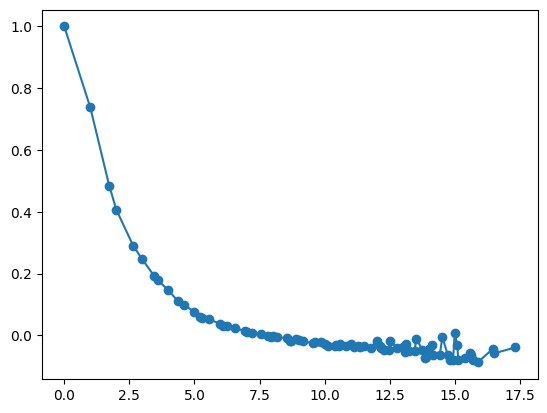

In [5]:
# Plot the correlation function
fig, ax = plt.subplots()
ax.plot(dist, corr_r, "o-")

In [6]:
# We use this function to extract the critical exponent of the correlation function
def fit_crit(r, G_inf, C, p):
    y = G_inf + C / r ** (p)
    return y

In [7]:
# We only fit the part of the correlation function that is not affected by
#   finite-size effects
start = np.where(dist > 0)[0][0]
end = np.where(dist <= L // 2)[0][-1]

# Fit the correlation function to extract the critical exponent
parameters, covariance = curve_fit(
    fit_crit,
    dist[start:end],
    corr_r[start:end],
    bounds=([-2, 0, 0], [2, np.inf, 5]),
)

G_inf, C, p = parameters

/media/scratch/tmp/ipykernel_127378/2571486389.py:3: RuntimeWarning: divide by zero encountered in divide
  y = G_inf + C / r ** (p)


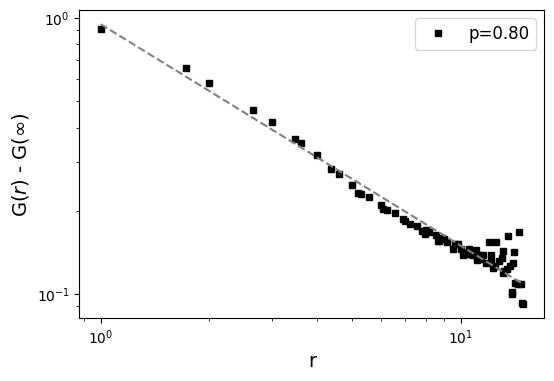

In [8]:
# Plot the correlation function and the fit on a log-log scale
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

fit_y = fit_crit(dist, *parameters)
ax.loglog(
    dist[start:end], corr_r[start:end] - G_inf,
    "s", markersize=4, color="black",
    label=f"p={parameters[-1]:.2f}",
)
ax.loglog(
    dist[start:end], fit_y[start:end] - G_inf,
    color="gray", linestyle="--",
)

ax.set_xlabel("r", fontsize=14)
ax.set_ylabel(r"G($r$) - G($\infty$)", fontsize=14)
ax.legend(fontsize=12, frameon=True, labelcolor="linecolor");

In [9]:
print(f"Critical exponent (underconverged) p = {p:.2f}")

Critical exponent (underconverged) p = 0.80


In [10]:
# Cleanup the temporary directory used to store the local markers
import shutil
shutil.rmtree(directory)